In [1]:
from pathlib import Path
from datetime import datetime
import quant
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings(action='ignore')

In [2]:
CONFIG_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "lseg-data.config.json"
STORE_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "data" / "fi_ltm_test"
session = quant.SessionProvider(CONFIG_PATH)

100%|██████████| 206/206 [00:02<00:00, 92.06it/s] 


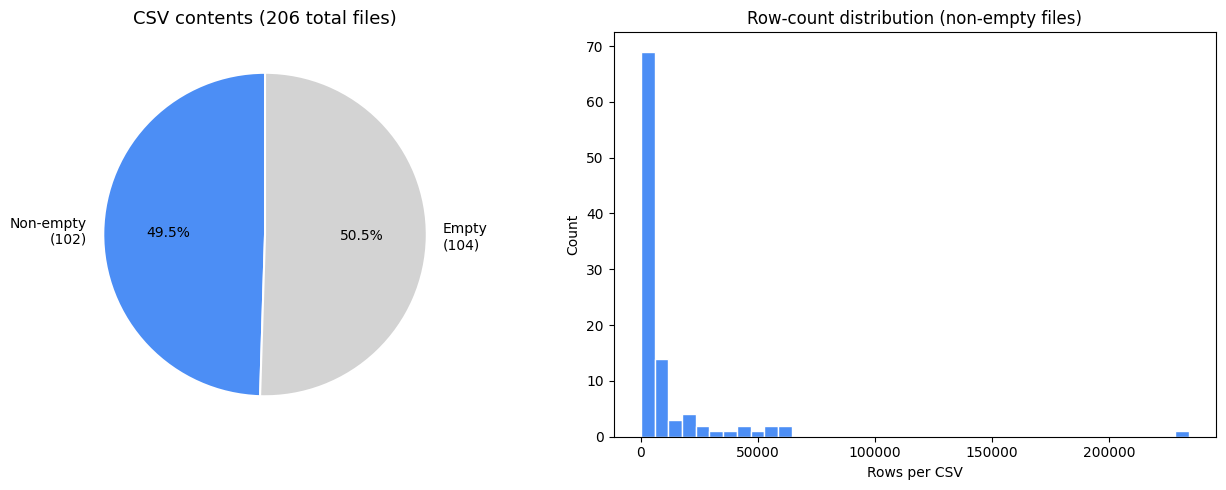

Total CSV files:      206
Non-empty:            102  (49.5%)
Empty:                104  (50.5%)

Row counts (non-empty files):
n_files           102.000000
mean_rows       11003.274510
std_rows        26359.020153
min_rows           42.000000
25%              1312.750000
median_rows      3208.500000
75%              8668.250000
max_rows       234028.000000

Top 10 files by row count:
      file   rows  cols
  GE.N.csv 234028    34
 CAT.N.csv  63846    34
  BA.N.csv  61217    34
 RTX.N.csv  58390    34
  DE.N.csv  53286    34
 NSC.N.csv  50564    34
 LMT.N.csv  41987    34
 UPS.N.csv  41384    34
  WM.N.csv  37976    34
HON.OQ.csv  34390    34


In [3]:

csvs = list(STORE_PATH.glob("*.csv"))

records = []
for p in tqdm(csvs):
    try:
        df = pd.read_csv(p)
        records.append({"file": p.name, "rows": len(df), "cols": len(df.columns), "non_empty": len(df) > 0})
    except Exception:
        records.append({"file": p.name, "rows": 0, "cols": 0, "non_empty": False})

summary = pd.DataFrame(records)
non_empty = summary["non_empty"].sum()
empty = len(summary) - non_empty

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    [non_empty, empty],
    labels=[f"Non-empty\n({non_empty})", f"Empty\n({empty})"],
    colors=["#4C8EF5", "#D3D3D3"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
axes[0].set_title(f"CSV contents ({len(summary)} total files)", fontsize=13)

ne = summary[summary["non_empty"]]
axes[1].hist(ne["rows"], bins=40, color="#4C8EF5", edgecolor="white")
axes[1].set_xlabel("Rows per CSV")
axes[1].set_ylabel("Count")
axes[1].set_title("Row-count distribution (non-empty files)")

plt.tight_layout()
plt.show()

print(f"Total CSV files:      {len(summary)}")
print(f"Non-empty:            {non_empty}  ({non_empty/len(summary):.1%})")
print(f"Empty:                {empty}  ({empty/len(summary):.1%})")
print()
print("Row counts (non-empty files):")
print(ne["rows"].describe().rename({
    "count": "n_files", "mean": "mean_rows", "std": "std_rows",
    "min": "min_rows", "50%": "median_rows", "max": "max_rows",
}).to_string())
print()
print("Top 10 files by row count:")
print(ne.nlargest(10, "rows")[["file","rows","cols"]].to_string(index=False))


## Why are some CSVs empty?

A CSV is written for every equity that made it past the two early-exits in `data_agg.py` (no bonds, or bonds with no issue date). An empty CSV means `run_client` completed but `working_dfs` came back empty — no bond produced a usable time-series panel. The four causes:

| Cause | Where it fires | Typical equity |
|---|---|---|
| No stock BID/ASK from LSEG | Early return after stock fetch | Pink-sheet / delisted stocks |
| No IV history | Per-bond `continue` in feature loop | Spinoffs, recently-listed companies |
| No overlapping dates after join + dropna | `panel.shape[0] == 0` per-bond | Very new bonds, sparse LSEG data |
| Too few rows after feature engineering | `len(X) <= 5` per-bond | Short bond history, long rolling warmup |

A missing CSV is distinct: those equities never reached `run_client` because LSEG returned no bonds (or no issue dates) for the equity.